In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import json
import sys
import matplotlib.pyplot
import scipy.linalg

In [2]:
import plotly
import plotly.graph_objs as go

# Introduction to numerical methods

This lecture introduces the main ideas of linear algebra in the context of numerical computation.

The central objects are:
- vectors,
- matrices,
- linear transformations,
- permutations and determinants.

We use these structures to represent data, solve systems of equations, and describe geometric operations such as scaling, rotation, and projection.


János Török

# Class 2: Linear algebra

Linear algebra is the study of vectors, matrices, and the transformations between them. In numerical methods, these objects are used to represent data, model systems, and describe the geometry of problems.

The main topics of this lecture are:
- permutations,
- vector spaces,
- scalar products and norms,
- matrices and matrix multiplication,
- affine and linear transformations.


## Permutations

A permutation is an ordering of a finite set of elements. For example, the numbers $1,2,3$ can be reordered in several ways.

The purpose of studying permutations is that they describe how indices are rearranged. In linear algebra, permutations are important in determinant calculations and in understanding the structure of matrices.

For the set $\{1,2,3\}$, the possible permutations are all reorderings of the three elements.


In [3]:
l = [ 1, 2, 3] # the list of numbers to be permuted
permutations = []
for i1 in range(3):
    for i2 in range(3):
        if i1 == i2: continue
        for i3 in range(3):
            if i1 == i3 or i2 == i3: continue
            permutations.append([ l[i1], l[i2], l[i3] ])

In [4]:
permutations

[[1, 2, 3], [1, 3, 2], [2, 1, 3], [2, 3, 1], [3, 1, 2], [3, 2, 1]]

It would be inefficient to write separate code for each list length. Instead, we write a general recursive algorithm.

The idea is:
- choose one element,
- recursively permute the remaining elements,
- attach the chosen element in front of each result.

This gives all possible reorderings of the list.

The recursion ends when only one element remains, because there is only one possible ordering in that case.


In [5]:
def rpermutations(l):
    print("Kukucs",l)
    # if we have one element return the list of list of it
    if len(l) == 1:
        print("I have only one element: ", l[0])
        return [l]
    # iterate through all elements
    permutations = []
    for i in range(len(l)):
        ltmp = l.copy()
        my = ltmp.pop(i) # remove the element from the list and permute the rest
        for r in rpermutations(ltmp):
            # we have to add all combinations
            permutations.append([my] + r)
    print("I am returning:", permutations)
    return permutations

In [6]:
l = [1, 2, 3, 4]
p = rpermutations(l)
print(p)

Kukucs [1, 2, 3, 4]
Kukucs [2, 3, 4]
Kukucs [3, 4]
Kukucs [4]
I have only one element:  4
Kukucs [3]
I have only one element:  3
I am returning: [[3, 4], [4, 3]]
Kukucs [2, 4]
Kukucs [4]
I have only one element:  4
Kukucs [2]
I have only one element:  2
I am returning: [[2, 4], [4, 2]]
Kukucs [2, 3]
Kukucs [3]
I have only one element:  3
Kukucs [2]
I have only one element:  2
I am returning: [[2, 3], [3, 2]]
I am returning: [[2, 3, 4], [2, 4, 3], [3, 2, 4], [3, 4, 2], [4, 2, 3], [4, 3, 2]]
Kukucs [1, 3, 4]
Kukucs [3, 4]
Kukucs [4]
I have only one element:  4
Kukucs [3]
I have only one element:  3
I am returning: [[3, 4], [4, 3]]
Kukucs [1, 4]
Kukucs [4]
I have only one element:  4
Kukucs [1]
I have only one element:  1
I am returning: [[1, 4], [4, 1]]
Kukucs [1, 3]
Kukucs [3]
I have only one element:  3
Kukucs [1]
I have only one element:  1
I am returning: [[1, 3], [3, 1]]
I am returning: [[1, 3, 4], [1, 4, 3], [3, 1, 4], [3, 4, 1], [4, 1, 3], [4, 3, 1]]
Kukucs [1, 2, 4]
Kukucs [2, 4]

We define the Levi-Civita symbol as
$$
\varepsilon_{a_1 a_2 a_3 \ldots a_n} =
\begin{cases}
+1, & \text{if } (a_1, a_2, \ldots, a_n) \text{ is an even permutation of } (1,2,\ldots,n), \\
-1, & \text{if } (a_1, a_2, \ldots, a_n) \text{ is an odd permutation of } (1,2,\ldots,n), \\
0, & \text{otherwise.}
\end{cases}
$$

A permutation is obtained by swapping positions of indices. For example,
$$
(1,2,3,4) \to (1,3,2,4)
$$
changes the order of two entries and therefore is a transposition.

For the special case $n=3$, the symbol is
$$
\varepsilon_{ijk} =
\begin{cases}
+1, & \text{if } (i,j,k) \text{ is } (1,2,3), (2,3,1), \text{ or } (3,1,2), \\
-1, & \text{if } (i,j,k) \text{ is } (3,2,1), (1,3,2), \text{ or } (2,1,3), \\
0, & \text{if any two indices are equal.}
\end{cases}
$$

The Levi-Civita symbol is useful in determinant formulas and in expressing orientation in multiple dimensions.

(The value is $0$ if any two indeces are the same, $1$ if the indeces are in cyclic order and $-1$ if they are anticyclic)


In [7]:
def swap(l,i1,i2):
    tmp = l[i1]
    l[i1] = l[i2]
    l[i2] = tmp
    
def numberofswap(l1,l2):
    # we will modify l2, so do it on a copy
    ll2 = l2.copy()
    noswap = 0
    if len(l1) != len(ll2): # Just to be safe
        return "Error: the length of the arrays must be equal"
    for i in range(len(l1)):
        v = l1[i]
        try:
            j = ll2.index(v)
        except:
            return "Error: the lists differ in elements"
        if i != j:
            swap(ll2,i,j)
            noswap += 1
    return noswap

Now we create a 3-dimensional Levi-Civita tensor.

A tensor is a higher-dimensional generalization of a matrix or vector. In this case, $\varepsilon_{ijk}$ is a 3-index object whose entries are $+1$, $-1$, or $0$ depending on the permutation parity of $(i,j,k)$.

We compute it by enumerating all permutations of $(0,1,2)$ and counting how many swaps are needed to reach each ordering.


In [8]:
E = np.zeros((3,3,3),dtype=int)

In [9]:
for p in rpermutations([0,1,2]):
    ns = numberofswap([0,1,2],p)
    print(ns)
    if ns%2 == 0:
        E[p[0],p[1],p[2]] = 1
    else:
        E[p[0],p[1],p[2]] = -1

Kukucs [0, 1, 2]
Kukucs [1, 2]
Kukucs [2]
I have only one element:  2
Kukucs [1]
I have only one element:  1
I am returning: [[1, 2], [2, 1]]
Kukucs [0, 2]
Kukucs [2]
I have only one element:  2
Kukucs [0]
I have only one element:  0
I am returning: [[0, 2], [2, 0]]
Kukucs [0, 1]
Kukucs [1]
I have only one element:  1
Kukucs [0]
I have only one element:  0
I am returning: [[0, 1], [1, 0]]
I am returning: [[0, 1, 2], [0, 2, 1], [1, 0, 2], [1, 2, 0], [2, 0, 1], [2, 1, 0]]
0
1
1
2
2
1


In [10]:
E

array([[[ 0,  0,  0],
        [ 0,  0,  1],
        [ 0, -1,  0]],

       [[ 0,  0, -1],
        [ 0,  0,  0],
        [ 1,  0,  0]],

       [[ 0,  1,  0],
        [-1,  0,  0],
        [ 0,  0,  0]]])

### Vector space
A vector space is a collection of vectors that can be added together and multiplied by scalars while preserving the structure of the space.

In this course we mainly consider $n$-dimensional real vector spaces, although the same ideas also work with complex vectors.

The basic idea is that every vector $\mathbf{v} \in V$ is described relative to a basis, and linear operations are expressed as matrices acting on those vectors.


<b>Vectors</b>: A vector $\mathbf{v} \in V$ can be represented in Python as a 1-dimensional NumPy array or as an $n \times 1$ column matrix. In practice, 1D arrays are convenient, but some linear algebra operations are clearer when vectors are treated as column matrices.

For example:
- a 1D array such as `np.zeros(3)` is a vector representation,
- a 2D array with shape `(3, 1)` is a column vector,
- a 2D array with shape `(1, 3)` is a row vector.


In [11]:
a = np.zeros(3,dtype=float) # one dimensional array
b = np.ones((3,1),dtype=float) # column vector
c = np.ones((1,3),dtype=float) # row vector
print(a)
print(b)
print(c)

[0. 0. 0.]
[[1.]
 [1.]
 [1.]]
[[1. 1. 1.]]


The most basic operations in a vector space are addition and scalar multiplication. In linear algebra, the transpose of a matrix or vector swaps its rows and columns and is often used when working with row and column forms.

For example,
$$
\mathbf{v}^T \mathbf{u}
$$
represents a scalar product when the vectors are interpreted in the usual way.


In [12]:
print(c*3.7)
print(c+c)
print(b+c.T)

[[3.7 3.7 3.7]]
[[2. 2. 2.]]
[[2.]
 [2.]
 [2.]]


For sake of exercise let us try complex numbers

In [13]:
z = np.ones(3,dtype=complex)
print(z)

[1.+0.j 1.+0.j 1.+0.j]


In [14]:
#As you can see the complex unit is denoted by j
z[1] = 5+3.6j
print(z,z.real,z.imag)

[1.+0.j  5.+3.6j 1.+0.j ] [1. 5. 1.] [0.  3.6 0. ]


### Scalar product
The scalar product of two vectors $\mathbf{a}$ and $\mathbf{b}$ is defined by
$$
(\mathbf{a}, \mathbf{b}) = \sum_{i=1}^{n} a_i b_i.
$$

This quantity measures how strongly two vectors point in the same direction. It is also the foundation of the concept of length and angle in Euclidean space.


In [15]:
#elementwise multiplication:
a = np.arange(3)
b = np.arange(1,4)

print(a,b,a * b,(a*b).sum())

[0 1 2] [1 2 3] [0 2 6] 8


`numpy.dot(a, b)` is a general function for computing dot products and matrix multiplication.

Its behavior depends on the shapes of the inputs:
- if both inputs are 1D arrays, it computes the inner product,
- if both are 2D arrays, it performs matrix multiplication,
- if one input is scalar, it behaves like ordinary multiplication.

In modern NumPy code, `@` or `np.matmul` is often clearer for matrix multiplication, but `np.dot` is still perfectly valid for many cases.


In [16]:
print(np.dot(a,b))
#other uses but I will mostly stick with the previous one:
print(a.dot(b),b.dot(a))

8
8 8


Length of a vector
$$
\|\mathbf{a}\| = \sqrt{(\mathbf{a},\mathbf{a})}.
$$

The norm of a vector measures its length. In numerical work, norms are used to compare sizes, check convergence, and quantify errors.


In [17]:
#however `numpy.linalg.norm` is preferred
print(np.sqrt(np.dot(a,a)),np.linalg.norm(a))

2.23606797749979 2.23606797749979


## Matrix
A matrix $A$ is a rectangular array of numbers with $m$ rows and $n$ columns. We write
$$A =
\begin{pmatrix}
 a_{11} & a_{12} & \cdots & a_{1n} \\
 a_{21} & a_{22} & \cdots & a_{2n} \\
 \vdots & \vdots & \ddots & \vdots \\
 a_{m1} & a_{m2} & \cdots & a_{mn}
\end{pmatrix}.
$$

A matrix can act on vectors and on other matrices. This is the foundation of linear transformations.

### Product of a matrix and a vector
If $A$ is an $m \times n$ matrix and $\mathbf{v}$ is an $n$-dimensional vector, then
$$
(A\mathbf{v})_i = \sum_{j=1}^{n} A_{ij} v_j.
$$

### Product of two matrices
If $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{n \times p}$, then $C = AB$ is an $m \times p$ matrix with entries
$$
(AB)_{ij} = \sum_{k=1}^{n} a_{ik} b_{kj}.
$$

This formula says that each entry of the product is a weighted sum of corresponding terms from row $i$ of $A$ and column $j$ of $B$.


In [18]:
m = 4
n = 3
p = 2
A = np.random.randint(5,size=(m,n))
v = np.random.randint(5,size=(n,1))
w = v[:,0]
print("A=",A)
print("v=",v)
print("w=",w)
print("Av=",np.dot(A,v),"\n","Av=",np.matmul(A,v))
print("Aw=",np.dot(A,w),"\n","Aw=",np.matmul(A,w))

A= [[3 2 2]
 [4 3 3]
 [3 0 3]
 [3 1 4]]
v= [[3]
 [2]
 [1]]
w= [3 2 1]
Av= [[15]
 [21]
 [12]
 [15]] 
 Av= [[15]
 [21]
 [12]
 [15]]
Aw= [15 21 12 15] 
 Aw= [15 21 12 15]


Remarks: if $\mathbf{w}$ is defined as a vector, then the result of a matrix-vector product is also a vector. The shape of the result depends on how the vector is represented in NumPy.

For a column vector, the output is a column vector. For a 1D array, the output is usually a 1D array.


In [19]:
B = np.random.randint(5,size=(n,p))
print("B=",B)
print("C=",np.dot(A,B))
print("C=",np.matmul(A,B))

B= [[3 3]
 [0 0]
 [0 2]]
C= [[ 9 13]
 [12 18]
 [ 9 15]
 [ 9 17]]
C= [[ 9 13]
 [12 18]
 [ 9 15]
 [ 9 17]]


In [20]:
%%timeit
C = np.dot(A,B)

1.15 μs ± 79.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [21]:
%%timeit
C = np.matmul(A,B)

1.36 μs ± 15.1 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


How challenging is it to write a matrix multiplication by hand?

The idea is straightforward:
- each entry of the product is computed by summing over the shared dimension,
- this requires three nested loops in the most direct implementation.

This is a good example of why optimized numerical libraries are so important: the implementation is easy to understand but expensive to compute if written badly.


In [22]:
def mymm(A,B):
    m,n = A.shape
    nb,p = B.shape
    if n != nb:
        return "Incompatible matrix shapes"
    C = np.zeros((m,p),dtype=float)
    for mi in range(m):
        for pi in range(p):
            for ni in range(n):
                C[mi,pi] += A[mi,ni] * B[ni,pi]
    return C
        

In [23]:
mymm(A,B)

array([[ 9., 13.],
       [12., 18.],
       [ 9., 15.],
       [ 9., 17.]])

In [24]:
#get rid of one of the summation
def mymm2(A,B):
    m,n = A.shape
    nb,p = B.shape
    if n != nb:
        return "Incompatible matrix shapes"
    C = np.zeros((m,p),dtype=float)
    for mi in range(m):
        for pi in range(p):
            C[mi,pi] = (A[mi,:] * B[:,pi]).sum()
    return C
        

In [25]:
mymm2(A,B)

array([[ 9., 13.],
       [12., 18.],
       [ 9., 15.],
       [ 9., 17.]])

If the matrix $\mathbf{A}$ is square, say $n \times n$, then it has a determinant.

The determinant is a scalar that measures the scaling factor of the transformation represented by the matrix, and it also tells whether the matrix is invertible.

For an $n \times n$ matrix,
$$
\det(A) = \sum_{i_1,i_2,\ldots,i_n} \varepsilon_{i_1\cdots i_n}\, a_{1,i_1}\cdots a_{n,i_n}.
$$

For $n=2$,
$$
\det \begin{pmatrix} a & b \\ c & d \end{pmatrix} = ad - bc.
$$

For $n=3$,
$$
\begin{vmatrix} a & b & c \\ d & e & f \\ g & h & i \end{vmatrix}
= aei + bfg + cdh - ceg - bdi - afh.
$$


In [26]:
n = 3
A = np.random.randint(5,size=(n,n))
print(A)
print(np.linalg.det(A))

[[0 3 2]
 [1 0 1]
 [1 3 3]]
0.0


We can use permutations to calculate the determinant.

The determinant sums over all permutations of the indices, and the sign is determined by the parity of the permutation. This is exactly the connection between the Levi-Civita symbol and the determinant formula.


In [27]:
def mydet(A):
    d = 0.0
    n = len(A)
    for p in rpermutations(list(range(n))):
        d += A[(np.arange(n),p)].prod() * (-1)**numberofswap(list(range(n)),p)
    return d

In [28]:
mydet(A)

Kukucs [0, 1, 2]
Kukucs [1, 2]
Kukucs [2]
I have only one element:  2
Kukucs [1]
I have only one element:  1
I am returning: [[1, 2], [2, 1]]
Kukucs [0, 2]
Kukucs [2]
I have only one element:  2
Kukucs [0]
I have only one element:  0
I am returning: [[0, 2], [2, 0]]
Kukucs [0, 1]
Kukucs [1]
I have only one element:  1
Kukucs [0]
I have only one element:  0
I am returning: [[0, 1], [1, 0]]
I am returning: [[0, 1, 2], [0, 2, 1], [1, 0, 2], [1, 2, 0], [2, 0, 1], [2, 1, 0]]


np.float64(0.0)

## Linear operations
A linear operation is any transformation that preserves addition and scalar multiplication.

If $\mathbf{v}$ is a vector in $n$ dimensions, then all linear operations from $\mathbb{R}^n$ to $\mathbb{R}^m$ can be represented by an $m \times n$ matrix $A$:
$$
\mathbf{u} = A\mathbf{v}.
$$

This is the fundamental representation of linear maps in numerical linear algebra.


### Scaling
A scaling transformation changes the length of vectors in different coordinate directions.

In 2D, a diagonal scaling matrix has the form
$$
A =
\begin{pmatrix}
 a_1 & 0 \\
 0 & a_2
\end{pmatrix}.
$$

This matrix scales the $x$ direction by $a_1$ and the $y$ direction by $a_2$.


In [29]:
def scaling_matrix(a1,a2):
    A = np.zeros((2,2),dtype=float)
    A[0,0] = a1
    A[1,1] = a2
    return A
def plotarrow(v1,color,ls='solid'):
    l = np.linalg.norm(v1)
    plt.arrow(*origin, v1[0], v1[1],head_width=l/15, head_length=l/6, fc=color, ec=color, ls=ls)

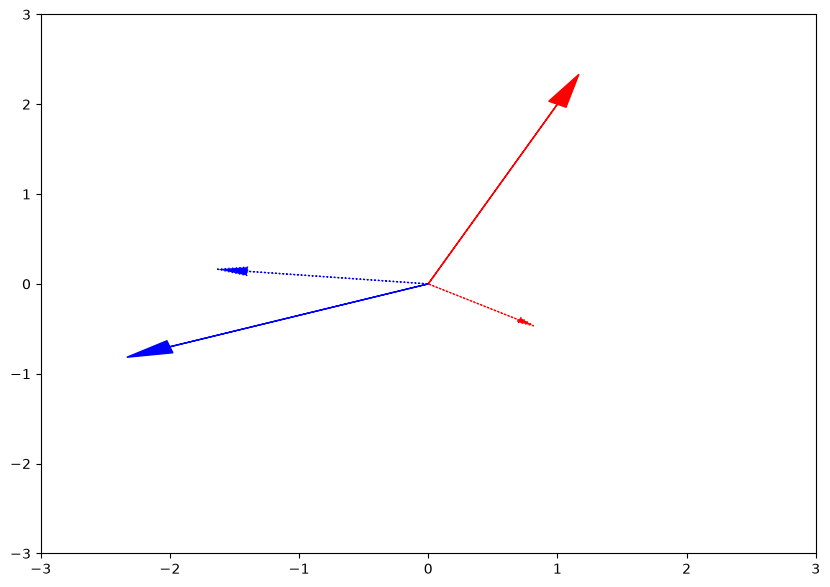

In [30]:
v1 = np.array([1,2])
v2 = np.array([-2,-0.7])
A = scaling_matrix(0.7,-0.2)
origin = [0,0]
plt.figure(figsize=(10,7))
plt.xlim(-3,3)
plt.ylim(-3,3)
plotarrow(v1,'r')
plotarrow(np.dot(A,v1),"r",ls="dotted")
plotarrow(v2,'b')
plotarrow(np.dot(A,v2),"b",ls="dotted")

In [31]:
v = np.zeros((6,2),dtype=float)
for i in range(6):
    v[i,0] = np.cos(2*np.pi *(2*i/5+0.05))
    v[i,1] = np.sin(2*np.pi *(2*i/5+0.05))

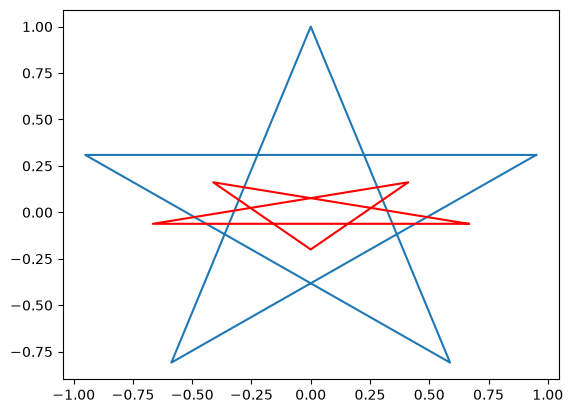

In [32]:
plt.plot(v[:,0],v[:,1])
u = np.dot(A,v.T).T
plt.plot(u[:,0],u[:,1],"r-")

### Projections
A projection takes a vector and maps it onto a line or plane in a chosen direction.

If the normal vector to the plane is $\mathbf{t}$, then the projection matrix onto that plane is
$$
P = \mathbf{t}\circ\mathbf{t} =
\begin{pmatrix}
 t_1t_1 & t_1t_2 \\
 t_1t_2 & t_2t_2
\end{pmatrix}
$$

after normalization of $\mathbf{t}$. This is useful for decomposing vectors into parts that lie along or perpendicular to a direction.


In [33]:
def projection(t):
    tt = t / np.linalg.norm(t)
    return np.outer(tt,tt)
    
#or
#tt = t / np.linalg.norm()
#return np.outer(t,t)/(t*t).sum()

In [34]:
t = np.array([1,2])
P = projection(t)
print(P)

[[0.2 0.4]
 [0.4 0.8]]


In [35]:
#Check whether its determinant is zero
print(np.linalg.det(P))

-2.2204460492503083e-17


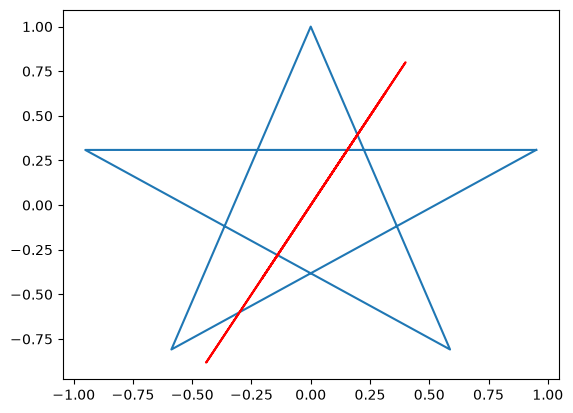

In [36]:
plt.plot(v[:,0],v[:,1])
u = np.dot(P,v.T).T
plt.plot(u[:,0],u[:,1],"r-")

### Rotation
A rotation matrix turns a vector by an angle $\phi$ around the $z$ axis.

In 2D, the matrix is
$$
R =
\begin{pmatrix}
 \cos(\phi) & -\sin(\phi) \\
 \sin(\phi) & \cos(\phi)
\end{pmatrix}.
$$

This transformation preserves the length of vectors and changes only their direction.


In [37]:
def rotation(phi):
    R = np.zeros((2,2),dtype=float)
    R[0,0] = R[1,1] = np.cos(phi)
    R[0,1] = - np.sin(phi)
    R[1,0] = np.sin(phi)
    return R

In [38]:
R = rotation(-np.pi/9)
print(np.linalg.det(R)) # should be one

1.0


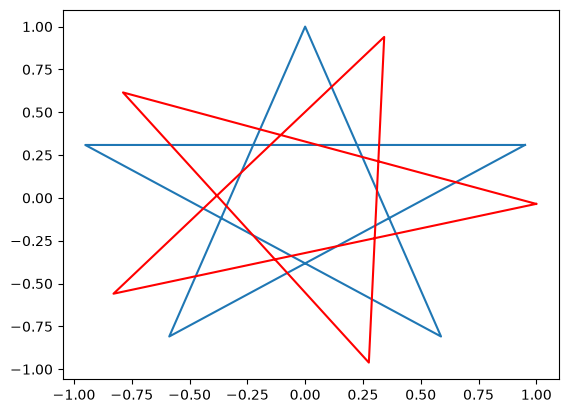

In [39]:
plt.plot(v[:,0],v[:,1])
u = np.dot(R,v.T).T
plt.plot(u[:,0],u[:,1],"r-")

### Affine transformations
Translation is not a linear transformation because it does not preserve the origin. In particular, the result of translation depends on the original location, not only on the vector itself.

For a vector $\mathbf{u}$ and a translation vector $\mathbf{t}$, we write
$$
\mathbf{u}' = \mathbf{u} + \mathbf{t}.
$$

Affine transformations combine linear maps with translations and are used to model rigid motion and geometric transformations in a general way.


In [40]:
def translate(u,t):
    return u+t

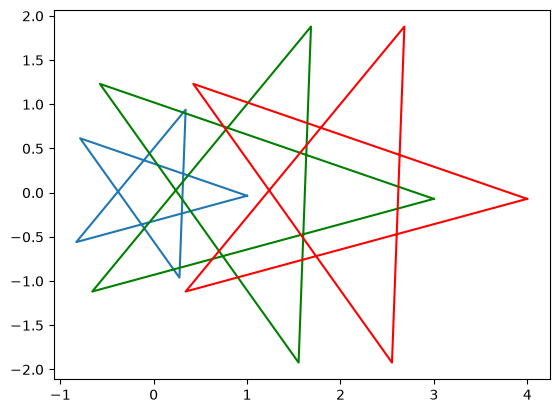

In [41]:
#translate vector
t = np.array([1,0])
# object multiplyed by 2 and the translated:
v1 = translate(u*2,t)
v2 = translate(u,t) * 2
plt.plot(u[:,0],u[:,1])
plt.plot(v1[:,0],v1[:,1],"g-")
plt.plot(v2[:,0],v2[:,1],"r-")

Translation is an <b>affine transformation</b>. The key trick is to augment the vector with an extra coordinate equal to $1$, so that the translation is represented as a matrix multiplication.

We write:
$$
\mathbf{u}' =
\begin{pmatrix}
\mathbf{u} \\
1
\end{pmatrix}.
$$

Then an affine transformation can be written in the form
$$
A' =
\begin{pmatrix}
1 & 0 \\
0 & 1 \\
 t_x & t_y
\end{pmatrix},
$$
so that
$$
\mathbf{v}'_j = \sum_{i=1}^{3} A'_{ji} u'_i = u_j + t_j.
$$

This representation allows us to combine translation with any linear transformation in a single matrix expression.


In [42]:
def translation(t):
    A = np.zeros((2,3),dtype=float)
    A[0,0] = 1
    A[1,1] = 1
    A[:,2] = t
    return A

In [43]:
T = translation(np.array([1,-0.5]))
print(T)

[[ 1.   0.   1. ]
 [ 0.   1.  -0.5]]


In [44]:
def tdot(T,u):
    if u.ndim == 1:
        uu = np.ones(3,dtype=float)
        uu[:2] = u
        return np.dot(T,uu)
    else:
        shape = list(u.shape)
        shape[0] += 1
        uu = np.ones(shape,dtype=float)
        uu[:-1] = u
        vT = np.dot(T,uu)
        return(vT.T)

In [45]:
tdot(T,u.T)

array([[ 1.99939083, -0.5348995 ],
       [ 0.21198925,  0.11566148],
       [ 1.27563736, -1.4612617 ],
       [ 1.34202014,  0.43969262],
       [ 0.17096243, -1.0591929 ],
       [ 1.99939083, -0.5348995 ]])

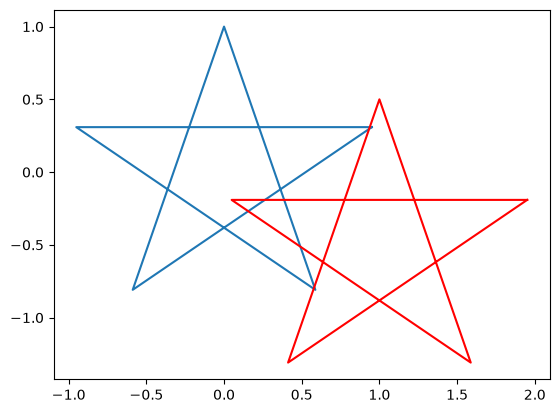

In [46]:
plt.plot(v[:,0],v[:,1])
u = tdot(T,v.T)
plt.plot(u[:,0],u[:,1],"r-")

As mentioned earlier We can you any linear transformation along with translation in the affine tansformation.

In [47]:
def affine(B,t):
    A = np.zeros((2,3),dtype=float)
    A[:2,:2] = B
    A[:,2] = t
    return A

In [48]:
A = affine(rotation(np.pi/4),np.array([1,-0.5]))
print(A)

[[ 0.70710678 -0.70710678  1.        ]
 [ 0.70710678  0.70710678 -0.5       ]]


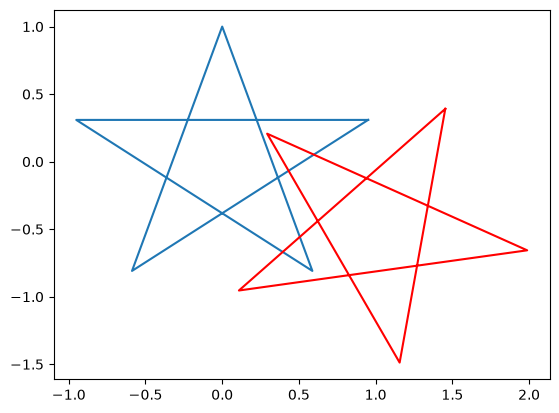

In [49]:
plt.plot(v[:,0],v[:,1])
u = tdot(A,v.T)
plt.plot(u[:,0],u[:,1],"r-")

## Affine transformations in 3D

In 3D, the same ideas apply, but now the vectors have three coordinates and the transformations act in space. To visualize the effect, we use Plotly to render geometric objects such as cubes.

The matrices we define represent transformations like:
- scaling,
- projection,
- rotation,
- translation.

A combination of these operations is called an affine transformation in 3D space.


In [50]:
# plot_cube takes the corners of a parallelepiped, and plots it.
#Arrays can be supplied instead of the coordinates and the color(s) for multiple objects
def plot_cube(X,Y,Z,color='blue'):
    if '[' in str(X[0]): # ] just close it :-)
        fig = go.Figure(data=[
             go.Mesh3d(
                # 8 vertices of a cube
                x=X[0],
                y=Y[0],
                z=Z[0],

                i = [0,3,0,5,0,6,4,7,2,7,1,7],
                j = [1,1,1,1,2,2,5,5,3,3,3,3],
                k = [2,2,4,4,4,4,6,6,6,6,5,5],
                opacity=0.6,
                color=color[0],
                flatshading = True
            )                    
            ])
        for i in range(1,len(X)):
            fig.add_trace(go.Mesh3d(
                # 8 vertices of a cube
                x=X[i],
                y=Y[i],
                z=Z[i],

                i = [0,3,0,5,0,6,4,7,2,7,1,7],
                j = [1,1,1,1,2,2,5,5,3,3,3,3],
                k = [2,2,4,4,4,4,6,6,6,6,5,5],
                opacity=0.6,
                color=color[i],
                flatshading = True
            ))
    else:
        fig = go.Figure(data=[
             go.Mesh3d(
                # 8 vertices of a cube
                x=X,
                y=Y,
                z=Z,

                i = [0,3,0,5,0,6,4,7,2,7,1,7],
                j = [1,1,1,1,2,2,5,5,3,3,3,3],
                k = [2,2,4,4,4,4,6,6,6,6,5,5],
                opacity=0.6,
                color=color,
                flatshading = True
            )                   
            ])
    fig.show()

In [51]:
X = np.arange(8)//4
Y = (np.arange(8)//2)%2
Z = np.arange(8)%2
plot_cube(X,Y,Z)

In [52]:
#two cubes (We shift the second by two units in the x direction to be able to see anything.)
plot_cube([X-1,X+1],[Y,Y],[Z,Z],color=['red','blue'])

## Transformations

This section summarizes the main geometric transformations used in linear algebra:

* Scaling: changes the size of vectors in coordinate directions.
* Projection: maps vectors onto a subspace or direction.
* Rotation: rotates vectors while preserving length.
* Translation: shifts vectors by a constant offset.

These operations can be combined to build more complex affine transformations.


In [53]:
#Scaling
def L_scale(A,alpha):
    return (A.T*alpha).T

In [54]:
#projection
def L_projection(A,t):
    tt = t / np.linalg.norm(t)
    return np.dot(np.identity(len(A)) - np.outer(tt,tt),A)

In [55]:
#projection
def L_rotation_xyz(A,alpha):
    ax = alpha[0]
    ay = alpha[1]
    az = alpha[2]
    Rx = np.array([[1.0,0.0,0.0],[0,np.cos(ax),-np.sin(ax)],[0,np.sin(ax),np.cos(ax)]])
    Ry = np.array([[np.cos(ay),0,np.sin(ay)],[0.0,1.0,0.0],[-np.sin(ay),0,np.cos(ay)]])
    Rz = np.array([[np.cos(az),-np.sin(az),0],[np.sin(az),np.cos(az),0],[0.0,0.0,1.0]])
    return np.dot(Rz,np.dot(Ry,np.dot(Rx,A)))

In [56]:
#translation, which we implement in a simple way
def L_translate(A,t):
    return (A.T+t).T

In [57]:
#coordinates:
X = np.arange(8)//4
Y = (np.arange(8)//2)%2
Z = np.arange(8)%2
# in a single matrix
A = np.concatenate((X,Y,Z)).reshape(3,-1)

In [58]:
B = L_scale(A,np.array([0.5,2,1.3]))
plot_cube([X-1,B[0]+1],[Y,B[1]],[Z,B[2]],color=['red','blue'])

In [59]:
B = L_projection(A,np.array([0.5,2,1.3]))
plot_cube([X-1,B[0]+1],[Y,B[1]],[Z,B[2]],color=['red','blue'])

In [60]:
B = L_rotation_xyz(A,np.array([np.pi/6,np.pi/4,np.pi/12]))
plot_cube([X-1,B[0]+1],[Y,B[1]],[Z,B[2]],color=['red','blue'])

In [61]:
#Let us shift the rotated matrix back
C = L_rotation_xyz(A,np.array([np.pi/6,np.pi/4,np.pi/12]))
B = L_translate(C,np.array([-2,0,0]))
plot_cube([X-1,B[0]+1],[Y,B[1]],[Z,B[2]],color=['red','blue'])